# Equipment Calibration for HI Lab: Part 1 of 3

This notebook is the **Part 1 (equipment-calibration) stage** in a three-part HI analysis chain:

1. **Part 1 (this notebook):** characterize attenuation, gain-scale linearity, reflectometry constraints, and hardware bandpass responses.
2. **Part 2 (`temperature_calibration.ipynb`):** apply intensity calibration to obtain physically scaled spectra.
3. **Part 3 (`analysis.ipynb`):** perform astrophysical line analysis (velocity-frame conversion, profile interpretation, and science products).

The goal here is to produce physically defensible calibration products with uncertainties and explicit requirement traceability to the lab handouts.

## Requirement Traceability (Part 1 Scope)

Primary references:

- `src/ugradio/lab_bighorn/bighorn.tex`
- `src/ugradio/lab_bighorn/cal_intensity.tex`
- `src/ugradio/lab_bighorn/horn_signal_chain_test.tex`
- `src/ugradio/lab_bighorn/coords.tex`

| ID | Requirement / theory item | Where addressed | Status |
|---|---|---|---|
| `R-SC-001` | Receiver chain gain/loss accounting (horn -> SDR) | Signal-chain gain sections + bench chain metrics | Covered |
| `R-SC-002` | Coax attenuation per meter near 1420 MHz | Shared-slope SDR + meter linear fits | Covered |
| `R-SC-003` | Unknown cable length inference with uncertainty | Inversion + Jacobian propagation | Covered |
| `R-SC-004` | SDR gain-scale linearity and clipping guardrails | Fixed-gain sweep diagnostics | Covered |
| `R-SC-005` | RTL2832U FIR + residual summing-filter response | FIR + cold_ref whitening + constrained optimization | Covered |
| `R-SC-006` | Reflectometry timing ambiguity and branch selection | Square-wave branch resolution and velocity-factor check | Covered |
| `R-SC-007` | VSWR/reflection-coefficient requirement awareness | Explicitly documented as a measurement gap | Covered with limitation |
| `R-CAL-001` | `cal_intensity.tex` cool-method calibration theory | Full derivation block below | Covered |
| `R-CAL-002` | First-order error propagation (sum/product/Jacobian) | Uncertainty derivation + implementation mapping | Covered |
| `R-COORD-001` | Coordinate transforms for sky/LSR analysis | Deferred to `analysis.ipynb` (Part 3), linked in handoff | Deferred intentionally |

## 1) Physical Setup and Modeling Assumptions

This section defines constants and assumptions used throughout Part 1.

### Hardware and measurement assumptions

- Coax attenuation over the sampled length range is modeled as first-order linear in dB: `y(L)=B-\alpha L`.
- Splitter and fixed attenuator losses are treated as additive constants in dB (intercept shifts), not slope changes.
- The 12-ft lead-in (`3.6576 m`) is subtracted only at the final unknown-cable estimate stage.

### Statistical assumptions

- Fit-parameter uncertainty combines OLS covariance with Monte Carlo perturbation from cable-length read uncertainty.
- Length inversion uncertainty is propagated by first-order Jacobian rules (consistent with `cal_intensity.tex`).

### Scope boundary

This notebook calibrates hardware terms used downstream; it does not perform sky-coordinate transforms or final astrophysical HI interpretation.

### Measurement-resolution inputs used for uncertainty propagation

- Ruler smallest division: `0.2 mm` -> per-read standard uncertainty proxy `sigma_L_read = 0.1 mm`.
- Power-meter smallest division: `0.2 dBm` -> per-read standard uncertainty proxy `sigma_P_read = 0.1 dB`.


## 2) Bench-Measured Signal-Chain Gain Context

The cumulative-gain plot uses **bench-probed block values** (dated 2026-03-07) to summarize end-to-end gain/loss structure from horn-side chain to SDR input.

Interpretation focus:

- verify that measured gain budget is plausible for ADC usage,
- identify anomalous losses (notably unexpectedly high K&L insertion loss),
- establish physically consistent priors for later calibration and safety checks.

## 3) Analysis Operators and Theory-to-Code Mapping

Helper functions below implement the mathematical operators used in this notebook.

### Model equations implemented

- Shared-slope SDR attenuation model:
  $$
  y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L
  $$
- Meter branch model:
  $$
  y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L
  $$
- Unknown-length inversion:
  $$
  L_i=\frac{B_i-y_i}{\alpha},\quad i\in\{1420,1421\}
  $$

### Error-propagation operators implemented

- `propagate_length_sigma(...)` for first-order Jacobian propagation,
- shared-fit covariance use for coupled parameters `[B_{1420}, B_{1421}, \alpha]`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

LAB02_DIR = Path.cwd().resolve()
if not (LAB02_DIR / "utils").exists():
    LAB02_DIR = (Path.cwd() / "labs" / "02").resolve()
if str(LAB02_DIR) not in sys.path:
    sys.path.insert(0, str(LAB02_DIR))

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

from utils import run_equipment_calibration
from utils.plotting import figure
from utils.tables import table

/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 4) Full `cal_intensity.tex` Cool-Method Derivation (Theory Alignment)

We reproduce the calibration logic used for spectral-line intensity scaling.

Start with the three measured spectra (channel index `j`):

$$
P_j^{ONLINE,CALOFF}=G_j\left(T_{sys}+T_{ant,HI}(\nu)\right),
$$
$$
P_j^{OFFLINE,CALOFF}=G_jT_{sys},
$$
$$
P_j^{OFFLINE,CALON}=G_j\left(T_{sys}+T_{cal}\right).
$$

From the first two equations,

$$
T_{sys}+T_{ant,HI}(\nu)=\left[\frac{P_j^{ONLINE,CALOFF}}{P_j^{OFFLINE,CALOFF}}\right]T_{sys}.
$$

The cool-method estimate of `T_sys` is obtained by band-averaging the noisy cal-difference ratio:

$$
T_{sys}=\frac{\sum_j P_j^{OFFLINE,CALOFF}}
{\sum_j\left(P_j^{OFFLINE,CALON}-P_j^{OFFLINE,CALOFF}\right)}\,T_{cal}.
$$

Substitution yields the calibrated spectrum estimate:

$$
T_{sys}+T_{ant,HI}(\nu)=
\left[\frac{P_j^{ONLINE,CALOFF}}{P_j^{OFFLINE,CALOFF}}\right]
\left[
\frac{\sum_j P_j^{OFFLINE,CALOFF}}
{\sum_j\left(P_j^{OFFLINE,CALON}-P_j^{OFFLINE,CALOFF}\right)}
\right]T_{cal}.
$$

Why cool beats naive: the channel-by-channel noisy denominator is replaced by a high-S/N band-averaged scale factor, reducing channel-scale noise while preserving line shape.

Part 1 note: this notebook focuses on hardware characterization terms that feed this calibration chain; full sky-line intensity products are produced in Part 2.

## 5) Data Ingest, Normalization, and QC Policy

We load attenuation and unknown-length manifests, validate required fields, normalize by source setpoint, and apply diagnostics-first screening.

Normalization used throughout:

$$
y = 10\log_{10}(P_{\mathrm{total}})-P_{\mathrm{siggen,dBm}}.
$$

This removes intentional source-level changes so slope estimates isolate cable-length dependence.

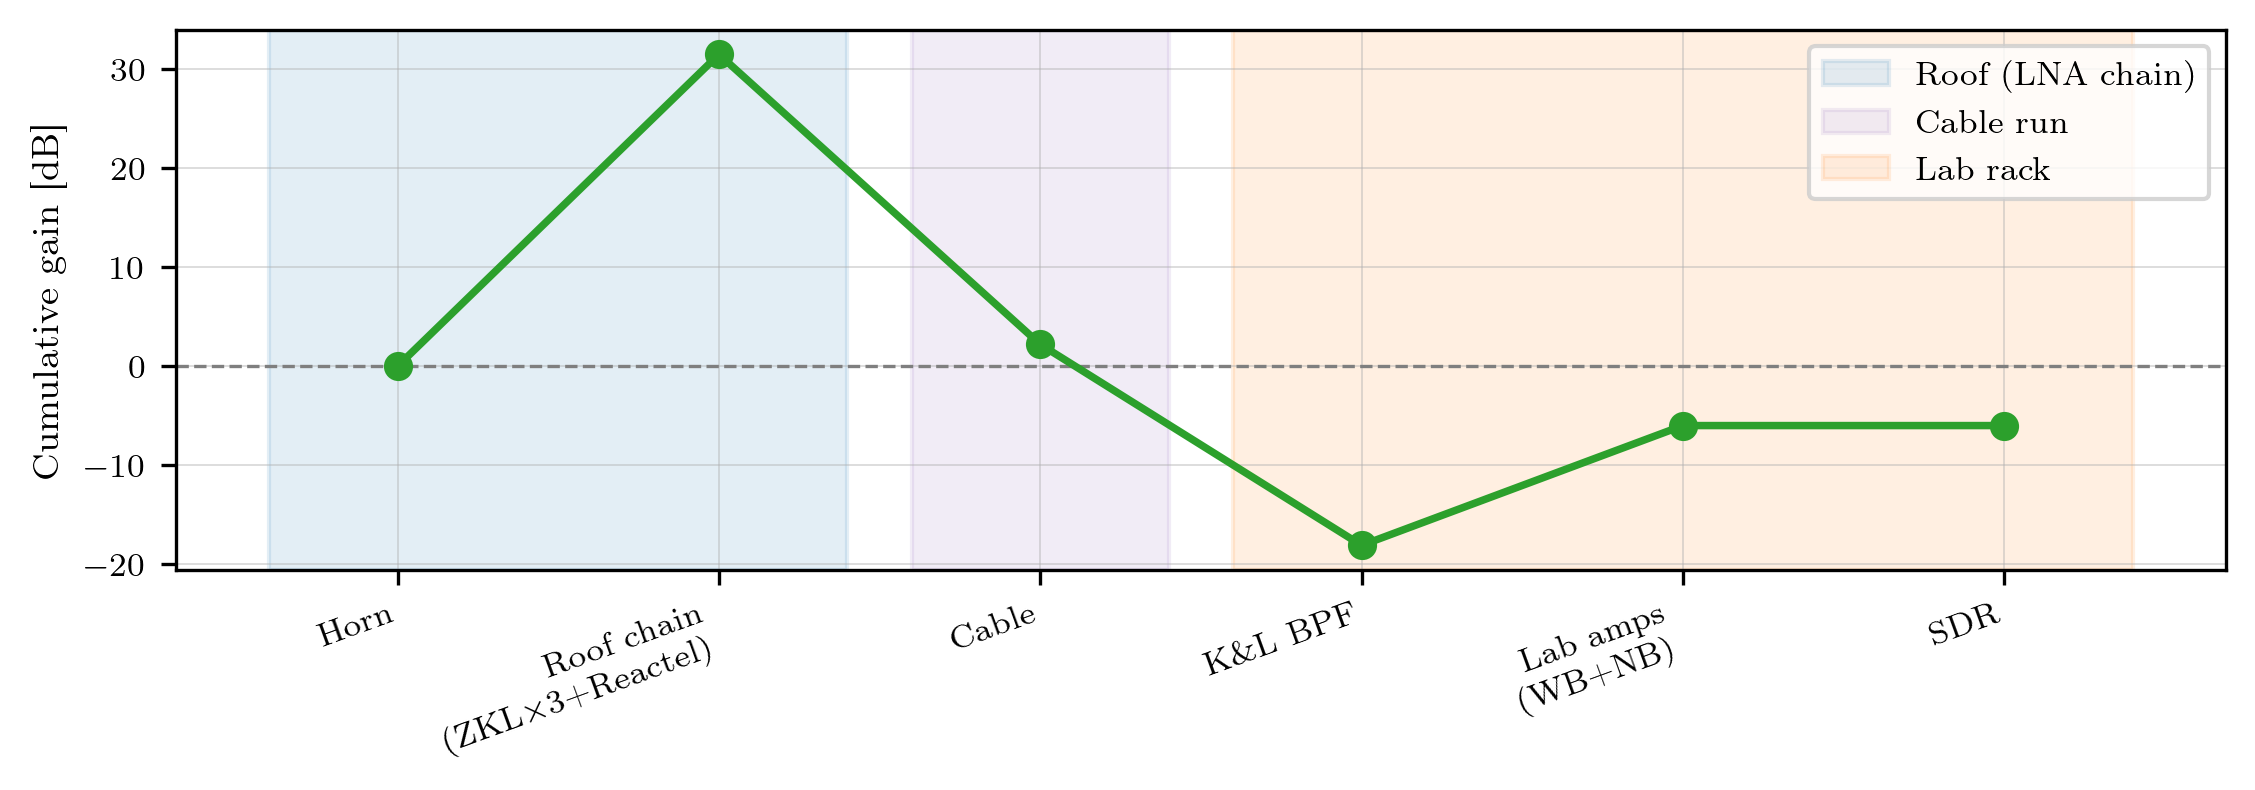

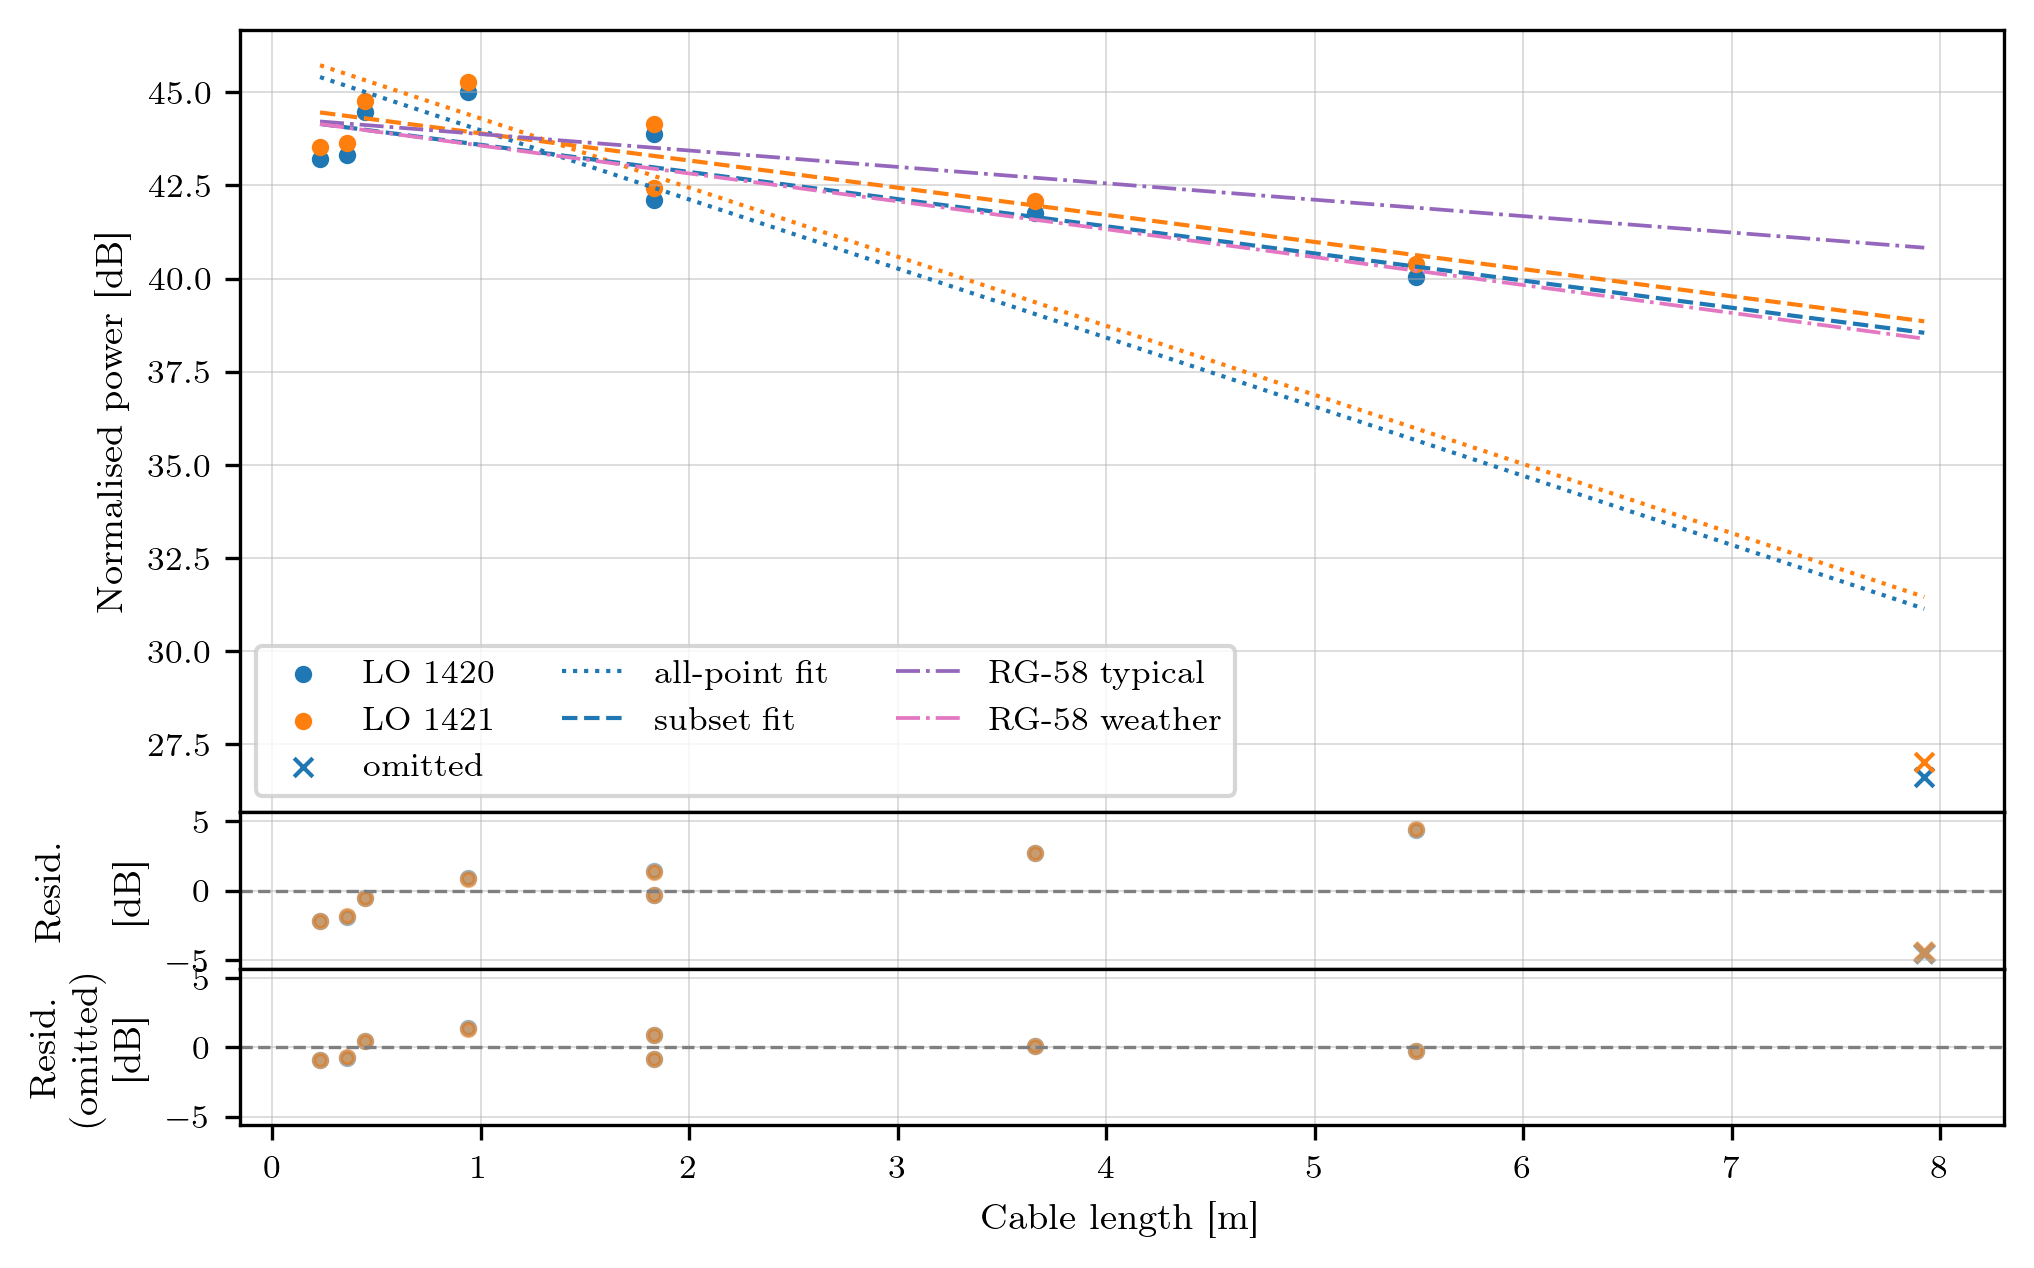

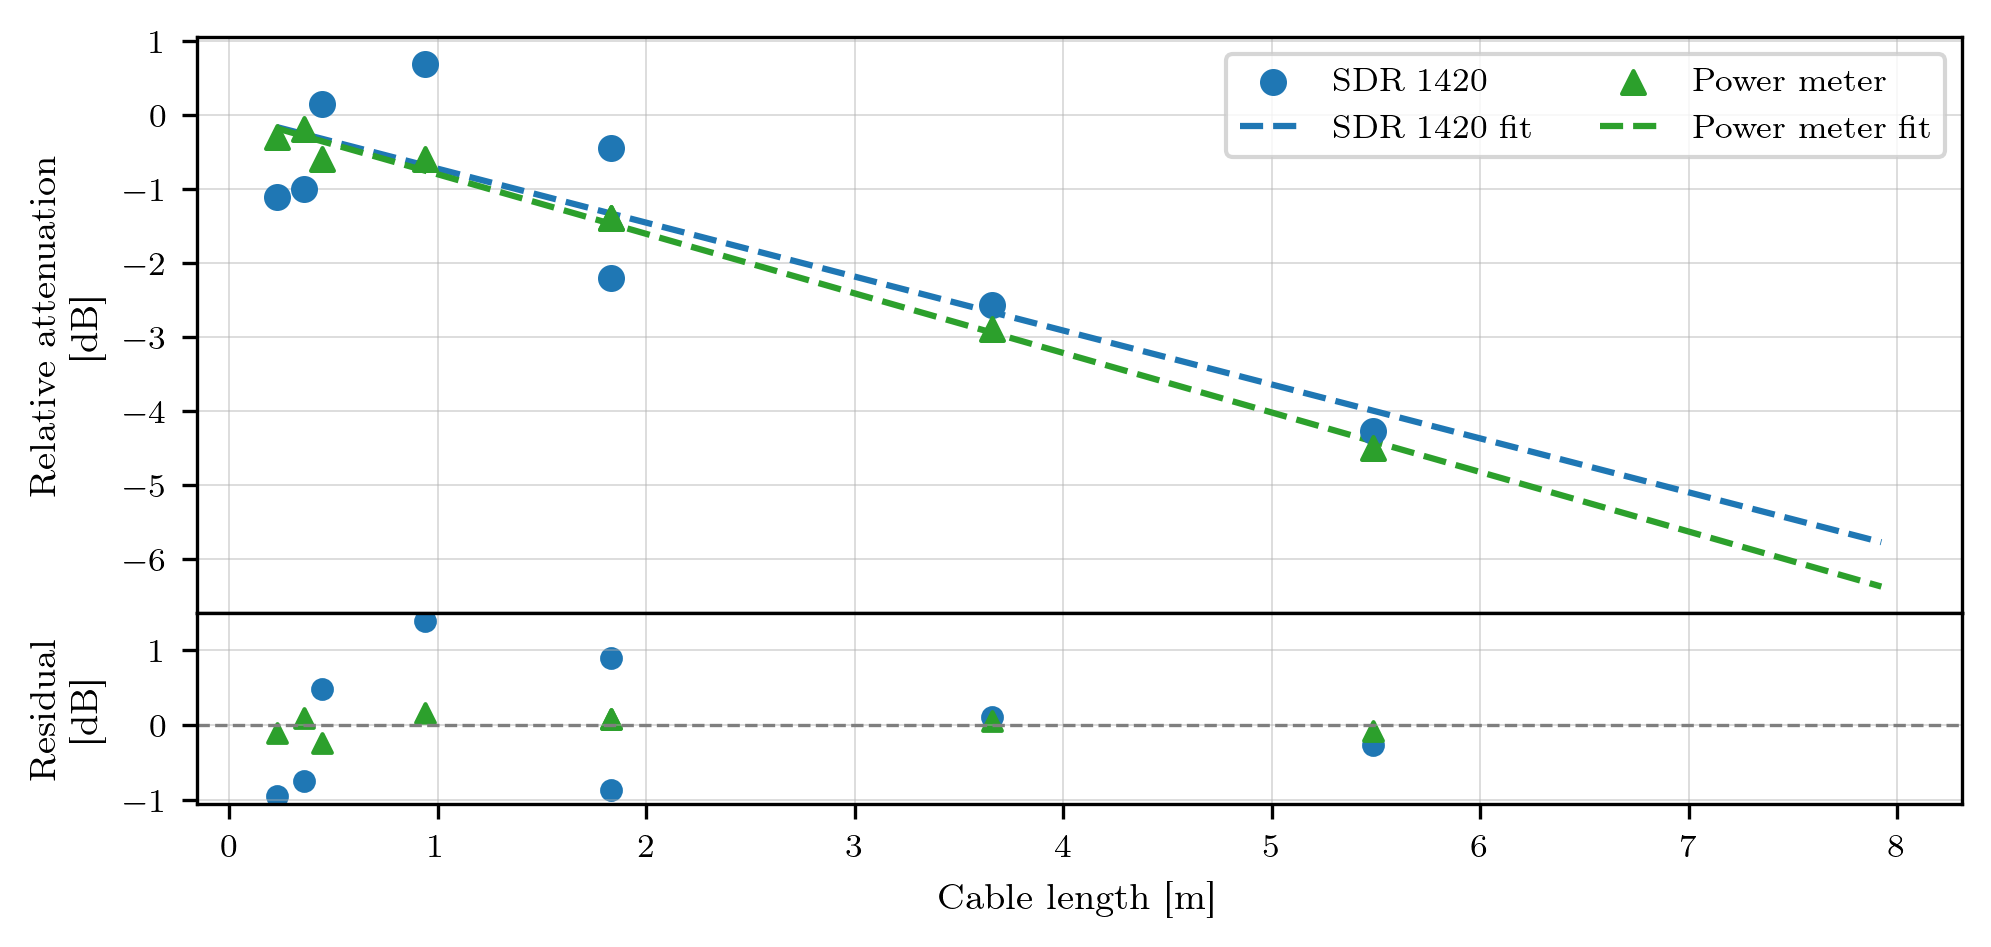

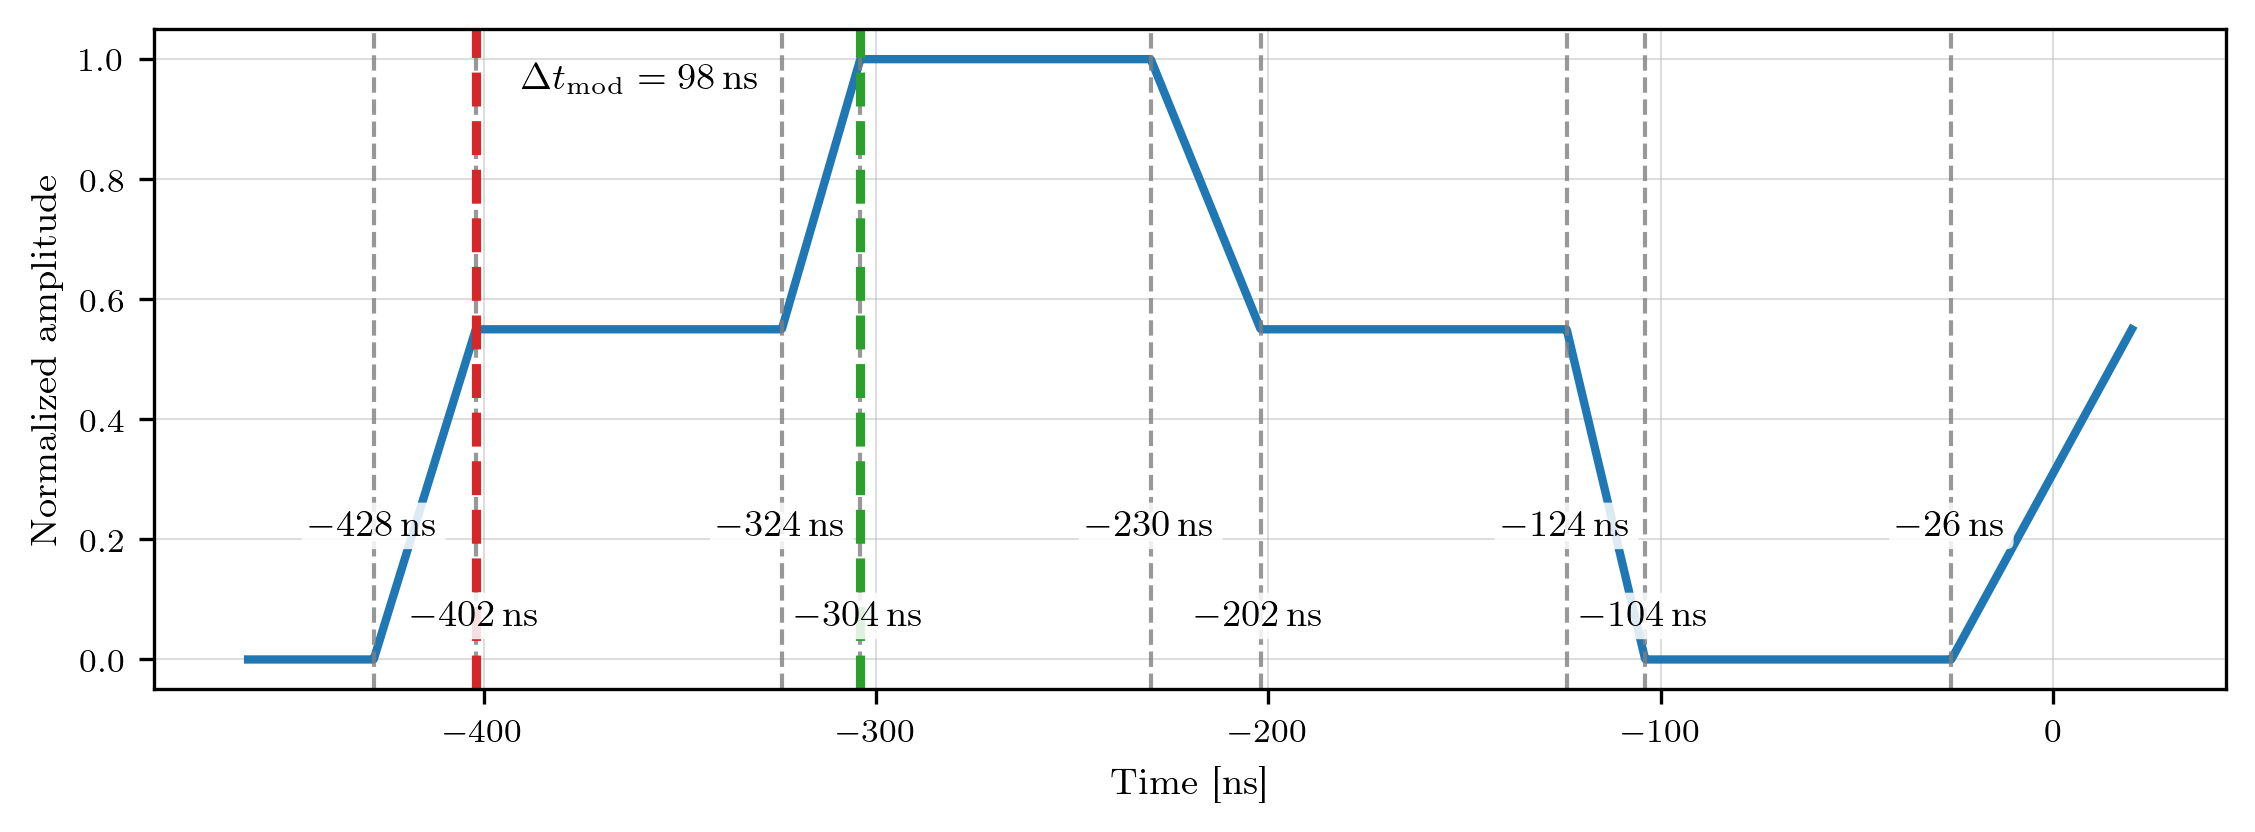

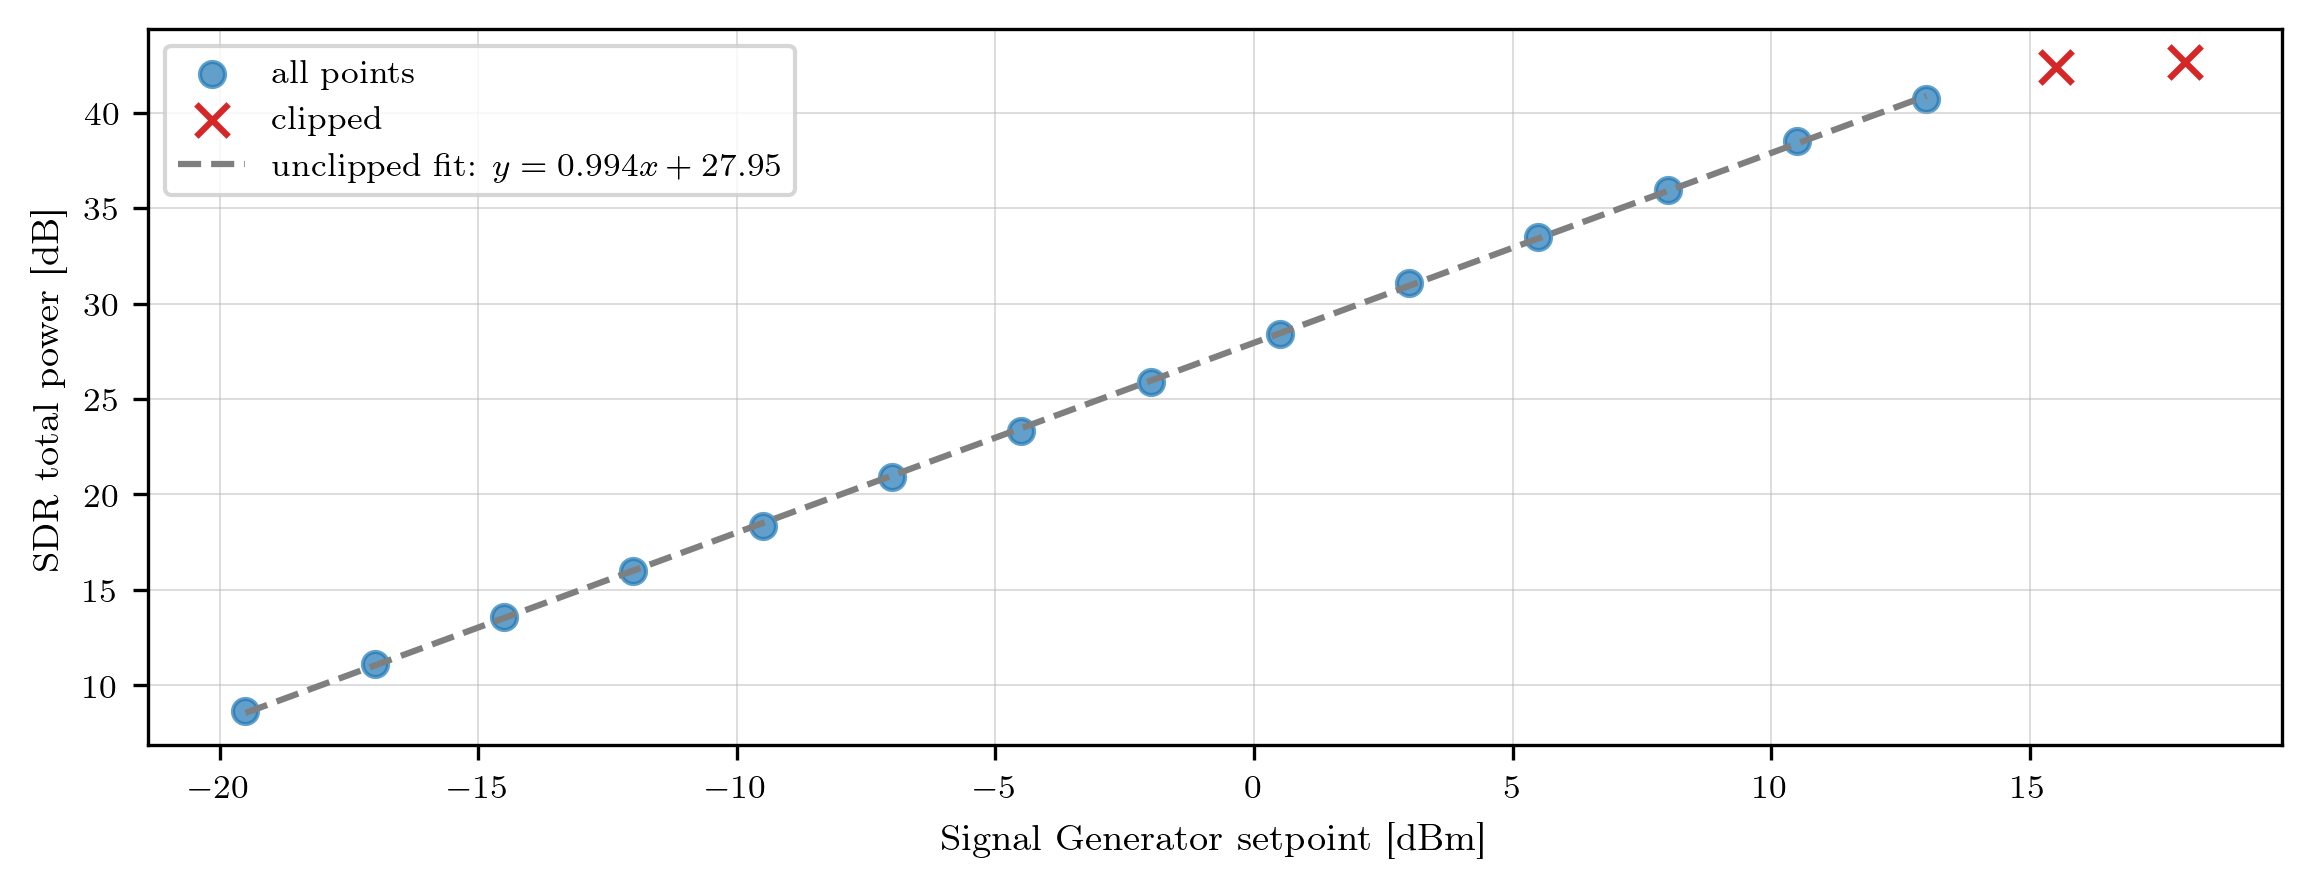

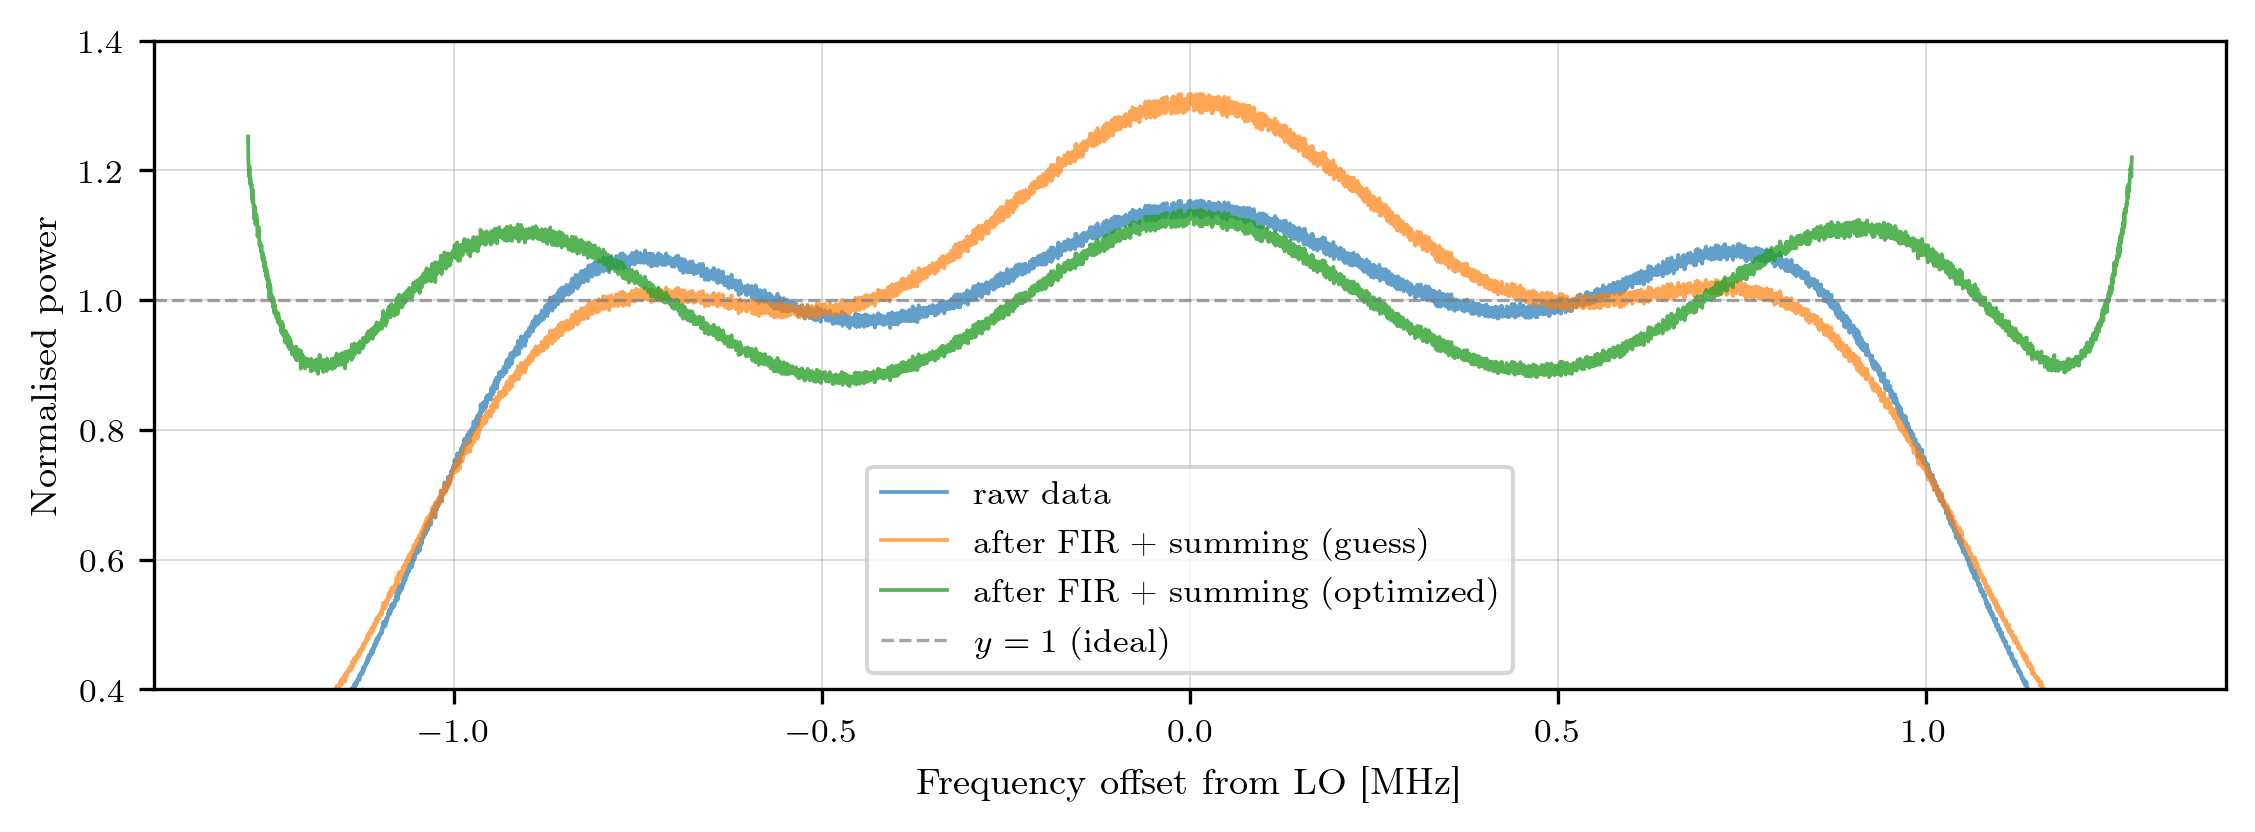

Part 1 produced `15` tables and `6` figures. Artifact: `/Users/junruiting/GitHub/ay-121/labs/02/cache/equipment_calibration_results_v2.npz`

In [2]:
equipment = run_equipment_calibration()
display(Markdown(
    f"Part 1 produced `{len(equipment.tables)}` tables and `{len(equipment.figures)}` figures. "
    f"Artifact: `{equipment.artifact_path}`"
))

In [3]:
for name in ["attenuation_primary", "unknown_manifest", "screening_diagnostics"]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(table(equipment, name))

### Attenuation Primary

,set_id,cable_length_m,power_meter_dbm,siggen_freq_mhz,siggen_amp_dbm,lo1420_path,lo1421_path,lo1420_total_power,lo1421_total_power,total_power_ratio_1420_over_1421,lo1420_i_min,lo1420_i_max,lo1420_i_median,lo1420_i_rms,lo1420_i_clip_frac,lo1420_q_min,lo1420_q_max,lo1420_q_median,lo1420_q_rms,lo1420_q_clip_frac,lo1421_i_min,lo1421_i_max,lo1421_i_median,lo1421_i_rms,lo1421_i_clip_frac,lo1421_q_min,lo1421_q_max,lo1421_q_median,lo1421_q_rms,lo1421_q_clip_frac,y_lo1420_db,y_lo1421_db,power_meter_norm_db
0,1,0.2286,-14.0000,1420.4058,-10.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,2089.0056,2248.5806,0.9290,-52.0000,51.0000,-1.0000,32.3248,0.0000,-52.0000,51.0000,-1.0000,32.3247,0.0000,-56.0000,55.0000,-1.0000,33.5363,0.0000,-56.0000,55.0000,-1.0000,33.5361,0.0000,43.1994,43.5191,-4.0000
1,2,0.3556,-8.9000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,6774.1958,7305.7710,0.9272,-92.0000,91.0000,-1.0000,58.2021,0.0000,-92.0000,91.0000,-1.0000,58.2021,0.0000,-100.0000,99.0000,-1.0000,60.4423,0.0000,-100.0000,99.0000,-1.0000,60.4423,0.0000,43.3086,43.6367,-3.9000
2,6,0.4445,-14.3000,1420.4058,-10.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,2796.6404,2992.5042,0.9345,-60.0000,59.0000,-1.0000,37.3993,0.0000,-60.0000,59.0000,-1.0000,37.3993,0.0000,-65.0000,64.0000,-1.0000,38.6864,0.0000,-65.0000,64.0000,-1.0000,38.6864,0.0000,44.4664,44.7603,-4.3000
3,4,0.9398,-9.3000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,10014.9316,10652.6553,0.9401,-112.0000,111.0000,-1.0000,70.7662,0.0000,-112.0000,111.0000,-1.0000,70.7662,0.0000,-120.0000,119.0000,-1.0000,72.9844,0.0000,-121.0000,119.0000,-1.0000,72.9843,0.0000,45.0065,45.2746,-4.3000
4,3,1.8288,-10.1000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,5144.8174,5543.8667,0.9280,-81.0000,80.0000,-1.0000,50.7227,0.0000,-81.0000,79.0000,-1.0000,50.7227,0.0000,-88.0000,86.0000,-1.0000,52.6529,0.0000,-88.0000,86.0000,-1.0000,52.6527,0.0000,42.1137,42.4381,-5.1000
5,5,1.8288,-10.1000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,7709.5684,8194.7920,0.9408,-99.0000,97.0000,-1.0000,62.0900,0.0000,-99.0000,98.0000,-1.0000,62.0901,0.0000,-106.0000,105.0000,-1.0000,64.0139,0.0000,-106.0000,105.0000,-1.0000,64.0140,0.0000,43.8703,44.1354,-5.1000
6,8,3.6576,-11.6000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,4730.2803,5096.5312,0.9281,-78.0000,76.0000,-1.0000,48.6367,0.0000,-78.0000,76.0000,-1.0000,48.6366,0.0000,-84.0000,83.0000,-1.0000,50.4842,0.0000,-84.0000,83.0000,-1.0000,50.4842,0.0000,41.7489,42.0727,-6.6000
7,9,5.4864,-13.2000,1420.4058,-5.0000,/Users/junruiting/GitHub/ay-121/data/lab02/att...,/Users/junruiting/GitHub/ay-121/data/lab02/att...,3198.2292,3458.0769,0.9249,-64.0000,63.0000,-1.0000,39.9938,0.0000,-64.0000,63.0000,-1.0000,39.9937,0.0000,-70.0000,68.0000,-1.0000,41.5863,0.0000,-70.0000,68.0000,-1.0000,41.5865,0.0000,40.0491,40.3883,-8.2000


### Unknown Manifest

,set_id,cable_length_m,power_meter_dbm,siggen_freq_mhz,siggen_amp_dbm,lo1420_path,lo1421_path,lo1420_total_power,lo1421_total_power,total_power_ratio_1420_over_1421,lo1420_i_min,lo1420_i_max,lo1420_i_median,lo1420_i_rms,lo1420_i_clip_frac,lo1420_q_min,lo1420_q_max,lo1420_q_median,lo1420_q_rms,lo1420_q_clip_frac,lo1421_i_min,lo1421_i_max,lo1421_i_median,lo1421_i_rms,lo1421_i_clip_frac,lo1421_q_min,lo1421_q_max,lo1421_q_median,lo1421_q_rms,lo1421_q_clip_frac,y_lo1420_db,y_lo1421_db,power_meter_norm_db
0,1,NaN,-15.5000,1420.4058,20.0000,/Users/junruiting/GitHub/ay-121/data/lab02/unk...,/Users/junruiting/GitHub/ay-121/data/lab02/unk...,1768.6278,1905.3022,0.9283,-52.0000,51.0000,-1.0000,29.7439,0.0000,-52.0000,51.0000,-1.0000,29.7438,0.0000,-58.0000,56.0000,-1.0000,30.8713,0.0000,-58.0000,56.0000,-1.0000,30.8712,0.0000,12.4764,12.7996,-35.5000


### Screening Diagnostics

,set_id,cable_length_m,siggen_amp_dbm,row_resid_norm_db,robust_z,inlier_resid,alpha_if_row_dropped,delta_alpha_loo,influence_flag
0,1,0.2286,-10.0000,3.1168,0.2451,True,1.9645,0.1113,False
1,2,0.3556,-5.0000,2.6236,0.0000,True,1.9406,0.0874,False
2,6,0.4445,-10.0000,0.7776,-0.9176,True,1.8778,0.0246,False
3,4,0.9398,-5.0000,1.2667,-0.6745,True,1.8238,0.0294,False
4,3,1.8288,-5.0000,0.4551,-1.0779,True,1.8576,0.0044,False
5,5,1.8288,-5.0000,1.9875,-0.3162,True,1.8338,0.0194,False
6,8,3.6576,-5.0000,3.8215,0.5954,True,1.9153,0.0622,False
7,9,5.4864,-5.0000,6.2214,1.7883,True,2.1646,0.3114,False
8,7,7.9248,5.0000,6.3236,1.8391,True,0.7281,1.1251,True


## 6) Path Corrections and Intercept Accounting

Known splitter/attenuator losses are applied as fixed dB offsets.

- These corrections shift intercept terms (`B`) but do not change `\alpha`.
- The short port-2 cable correction is deferred until `\alpha` is estimated.
- Unknown-length inversion remains invariant when the same fixed branch corrections apply consistently to calibration and unknown datasets.

## 7) Shared-Slope Attenuation Fit (Primary SDR Model)

We fit all points, perform residual and leave-one-out influence diagnostics, and select the primary fit according to the screening policy.

Core model:

$$
y_i(L)=B_i-\alpha L,\quad i\in\{1420,1421\}.
$$

### SDR Fit Interpretation

Interpretation targets:

- Is a single physically meaningful slope `\alpha` supported across LO branches?
- Do residuals show random scatter around zero without systematic curvature?
- Do screened and all-point fits differ in a way consistent with leverage/outlier diagnostics?

## 8) Uncertainty Propagation (First-Order, `cal_intensity`-style)

We use first-order propagation with covariance terms retained.

For
$$
L=\frac{B-y}{\alpha},
$$

Jacobian terms are
$$
\frac{\partial L}{\partial B}=\frac{1}{\alpha},\qquad
\frac{\partial L}{\partial y}=-\frac{1}{\alpha},\qquad
\frac{\partial L}{\partial \alpha}=-\frac{L}{\alpha}.
$$

Variance (including covariance between `B` and `\alpha`):
$$
\sigma_L^2=
\left(\frac{\partial L}{\partial B}\right)^2\sigma_B^2+
\left(\frac{\partial L}{\partial y}\right)^2\sigma_y^2+
\left(\frac{\partial L}{\partial \alpha}\right)^2\sigma_\alpha^2+
2\frac{\partial L}{\partial B}\frac{\partial L}{\partial \alpha}\operatorname{Cov}(B,\alpha).
$$

Shared-SDR unknown-length uncertainty additionally uses the full covariance on `[B_{1420}, B_{1421}, \alpha]`.

## 9) Model Scope and Why We Keep a Linear Attenuation Law

We intentionally keep the attenuation model linear in dB vs length for this dataset size.

- Sparse length sampling makes higher-order fits unstable.
- Unknown-length inversion is highly sensitive to slope uncertainty.
- Diagnostics are used to handle leverage/outlier behavior instead of adding unnecessary model degrees of freedom.

## 10) Independent Meter-Branch Cross-Check

We fit the meter branch independently and compare attenuation slopes with SDR-based estimates.

Agreement supports a path-independent physical attenuation interpretation; disagreement indicates branch-specific systematic effects (termination mismatch, readout offsets, connector state, or compression).

## 11) Voltage-Space Cross-Check (50 Ohm Matched Assumption)

We convert power-meter dBm readings to equivalent `V_rms` and `V_pp` under a matched 50 Ohm load.

This is an internal sanity check only, not the primary calibration path.

## 12) Bench Analog Measurement Log (2026-03-07)

This section documents the measured A1-A5 chain configurations and derives block-level gain/loss metrics.

It provides:

- chain closure checks,
- unknown-cable bench estimate for consistency,
- conservative drive-level safety guidance for cascaded amplifier tests.

### Filter/Amplifier Ordering and Noise Implications

Ordering affects both gain distribution and total in-band/out-of-band noise delivered to the ADC.

Following the logic in `horn_signal_chain_test.tex` and `bighorn.tex`, the objective is to preserve enough gain for robust digitization while constraining out-of-band amplification and reflection-induced artifacts.

## 13) Unknown-Cable Inversion and Primary-Estimate Selection

Unknown-length estimates:

$$
L_{1420}=\frac{B_{1420}-y_{1420}^{obs}}{\alpha},\quad
L_{1421}=\frac{B_{1421}-y_{1421}^{obs}}{\alpha},
$$
$$
L_{SDR}=\frac{L_{1420}+L_{1421}}{2},\quad
L_{meter}=\frac{B_{meter}-y_{meter}^{obs}}{\alpha_{meter}},
$$
$$
L_{unknown}=L_{total}-L_{lead}.
$$

Primary-source decision is criterion-based (SDR first; meter fallback if SDR stability criteria fail).

### Unknown-Length Cross-Checks

We compare manifest SDR, manifest meter, and bench analog estimates to verify calibration closure and to expose systematic offsets before exporting downstream calibration products.

## 14) Reflectometry Branch Resolution for Cable Velocity

Square-wave reflectometry provides round-trip delay constraints; periodic ambiguity is resolved by branch selection:

$$
\Delta t_n=\Delta t_{mod}+nT.
$$

Using unknown-cable length priors from the manifest inversion, we compute

$$
v_{coax}=\frac{2L}{\Delta t_n}
$$

and select physically plausible branches against expected velocity factor.

### VSWR / Reflection-Coefficient Requirement Status

`bighorn.tex` asks for VSWR/reflection quantification. This notebook includes timing-based reflectometry for propagation speed, but does not directly measure `|\Gamma|` or VSWR because incident/reflected amplitudes were not separately instrumented (no directional coupler/VNA in this run).

Resulting impact: mismatch effects may remain folded into empirical attenuation terms.

## 15) Consolidated Part-1 Summary Tables

Summary tables collect fit quality, attenuation products, unknown-length estimates with uncertainties, and selection rationale for the exported primary estimate.

In [4]:
for name in [
    "fit_compare",
    "estimate_summary",
    "fit_quality",
    "meter_compare",
    "meter_voltage",
    "unknown_crosscheck",
    "reflectometry_branches",
]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(table(equipment, name))

### Fit Compare

,n_rows,alpha [dB/m],sigma_alpha,B1420 [dB],B1421 [dB],RMSE [dB],AIC,BIC
fit_case,,,,,,,,
all-point,9,1.8532,0.2607,45.8281,46.1454,2.5415,39.5786,42.2497
primary-screened,8,0.7281,0.1269,44.3146,44.6224,0.7953,-1.3297,0.9880


### Estimate Summary

,L_unknown [m],Uncertainty,Notes
Estimate,,,
Manifest SDR,40.059,"[32.71, 47.41]",analytic +/-1sigma
Manifest meter,35.903,+/- 1.379 m,analytic propagation
Selected primary,40.059,+/- 7.346 m,manifest_sdr_linear
Bench analog,36.455,+/- 1.335 m,consistency cross-check


### Fit Quality

...

,set_id,cable_length_m,power_meter_dbm,power_w,v_rms_v,v_pp_v
0,1,0.2286,-14.0000,0.0000,0.0446,0.1262
1,2,0.3556,-8.9000,0.0001,0.0803,0.2270
2,6,0.4445,-14.3000,0.0000,0.0431,0.1219
3,4,0.9398,-9.3000,0.0001,0.0766,0.2168
4,3,1.8288,-10.1000,0.0001,0.0699,0.1977
5,5,1.8288,-10.1000,0.0001,0.0699,0.1977
6,8,3.6576,-11.6000,0.0001,0.0588,0.1664
7,9,5.4864,-13.2000,0.0000,0.0489,0.1384


### Unknown Crosscheck

,source,L_unknown_m,sigma_m,value_pm_sigma_m
0,Manifest SDR,40.0589,7.3462,40.0589 +/- 7.3462
1,Manifest meter,35.9035,1.3790,35.9035 +/- 1.3790
2,Bench analog,36.4550,1.3348,36.4550 +/- 1.3348
3,Selected primary,40.0589,7.3462,40.0589 +/- 7.3462


### Reflectometry Branches

,n,delta_t_ns,v_sdr_mps,v_sdr_sigma_mps,v_sdr_over_c,v_sdr_over_c_sigma,v_meter_mps,v_meter_sigma_mps,v_meter_over_c,v_meter_over_c_sigma
0,0,98.0000,817529131.7553,149922621.3654,2.7270,0.5001,732723734.7872,28142986.3270,2.4441,0.0939
1,1,498.0000,160879226.7310,29502845.1683,0.5366,0.0984,144190614.4762,5538178.0322,0.4810,0.0185
2,2,898.0000,89218101.2383,16361266.0287,0.2976,0.0546,79963169.2752,3071283.5858,0.2667,0.0102
3,3,1298.0000,61724079.2851,11319273.4159,0.2059,0.0378,55321206.4785,2124817.1495,0.1845,0.0071


### Physical Plausibility Against Coax Expectations

Measured attenuation slopes are compared against RG-58-family expectations near 1420 MHz to test whether fitted values are physically credible and to flag mechanically compromised calibration points.

### Additional Consistency Diagnostics

This section records agreement/disagreement patterns across screened vs all-point fits, manifest vs bench estimates, and safety/compression constraints used for conservative bench operation.

## 16) SDR Gain-Sweep Linearity and Clipping Guardrails

We analyze fixed-gain sweep data to identify the usable linear-response range and clipping thresholds that constrain reliable calibration operation.

### Sweep Fit

,lo_mhz,n_points,n_unclipped,n_clipped,highest_unclipped_setpoint_dbm,first_clipped_setpoint_dbm,slope_total_power_db_per_dbm,rmse_db,r2,meter_minus_set_mean_db,meter_minus_set_std_db
0,1420.0000,16,14,2,13.0000,15.5000,0.9943,0.0979,0.9999,-3.3937,0.1197


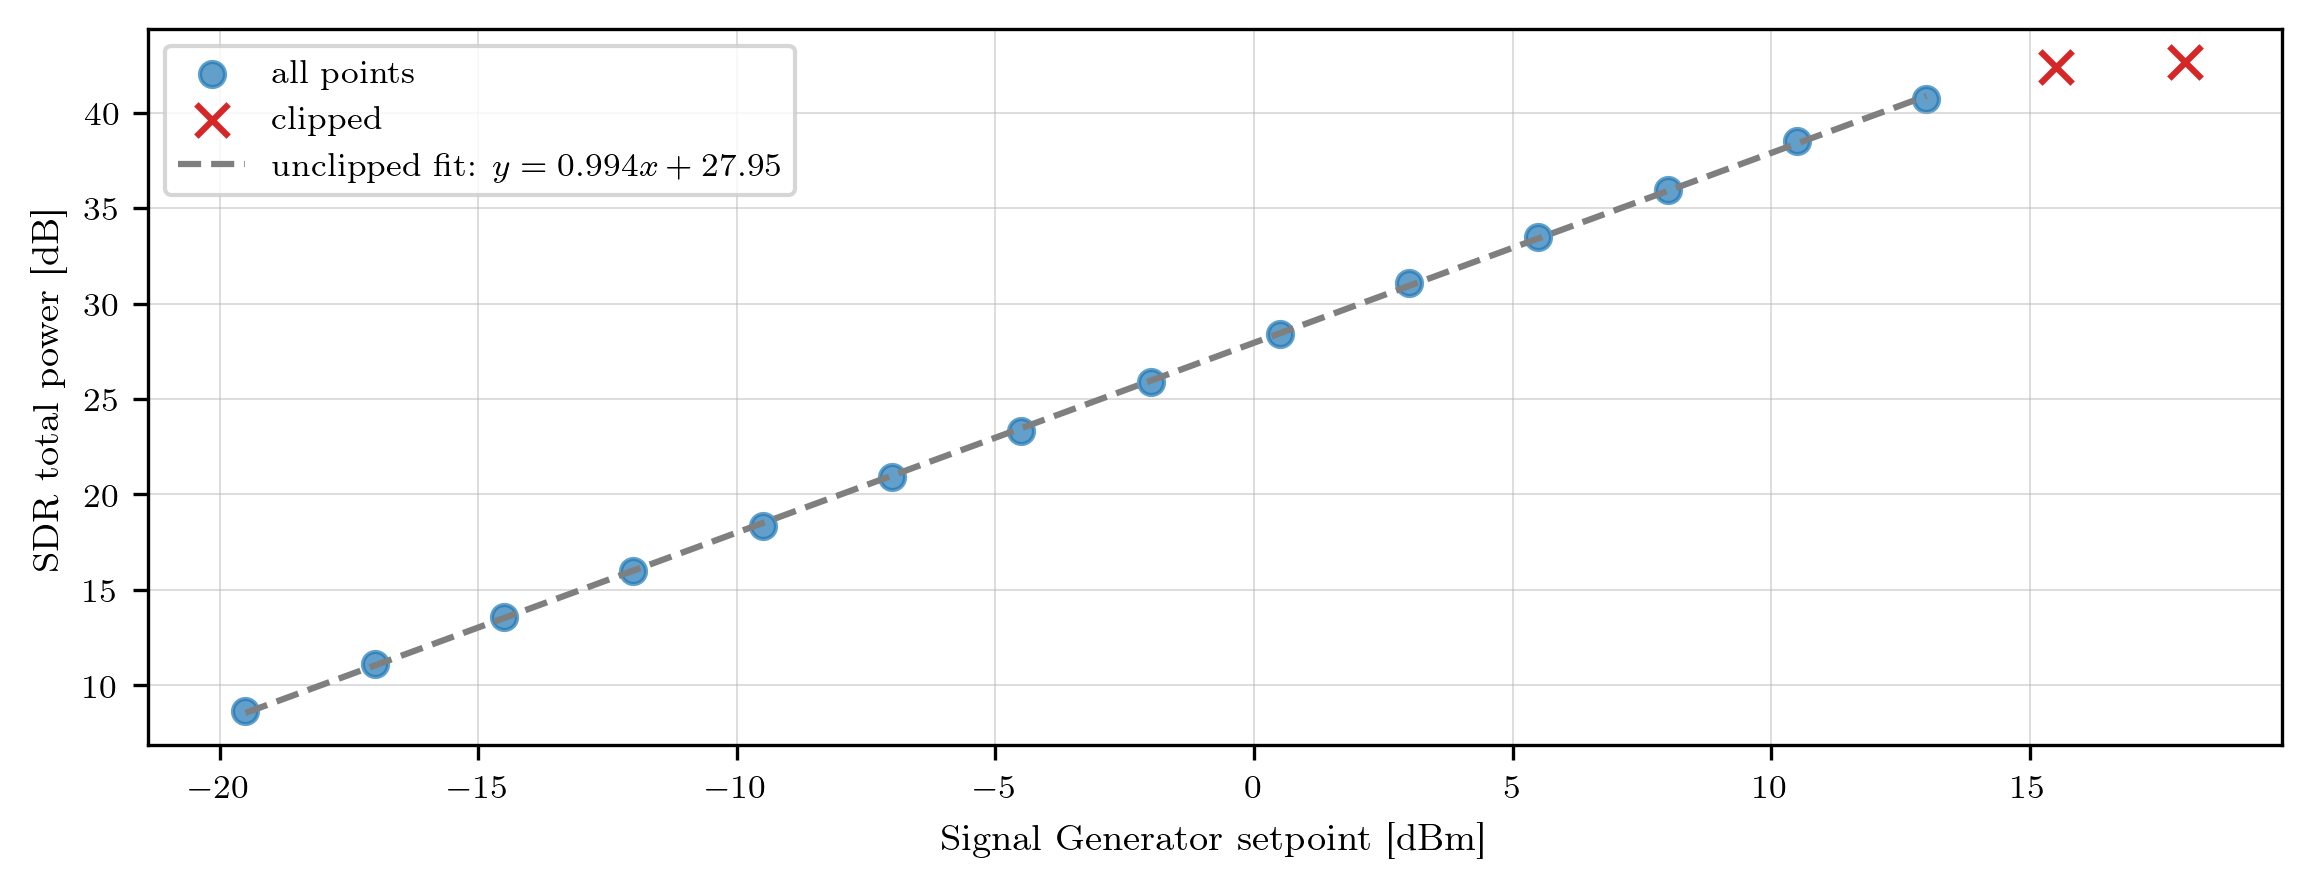

In [5]:
display(Markdown("### Sweep Fit"))
display(table(equipment, "sweep_fit"))
display(figure(equipment, "sdr_gain_response_clipping"))

## 17) Part-2 / Part-3 Handoff and Scope Boundary

### Outputs consumed downstream

- attenuation and unknown-length calibration terms,
- linearity guardrails,
- FIR/summing response arrays and evaluation masks.

### Coordinate-theory boundary

`coords.tex` implementation and sky-frame transforms are intentionally handled in `analysis.ipynb` (Part 3), not in this equipment notebook.

## 18) RTL2832U FIR and Summing-Filter Response Modeling

Using `bighorn.tex` default FIR coefficients and the estimated secondary summing filter, we model response on the measured output-frequency grid and define passband support masks for robust correction.

### Response Summary

,metric,value
0,FIR passband ripple [dB],3.1692
1,Combined passband ripple [dB],1.0541
2,Whitened frac std after FIR,0.1731
3,Whitened frac std after optimized FIR+sum,0.0816


### Signal Chain

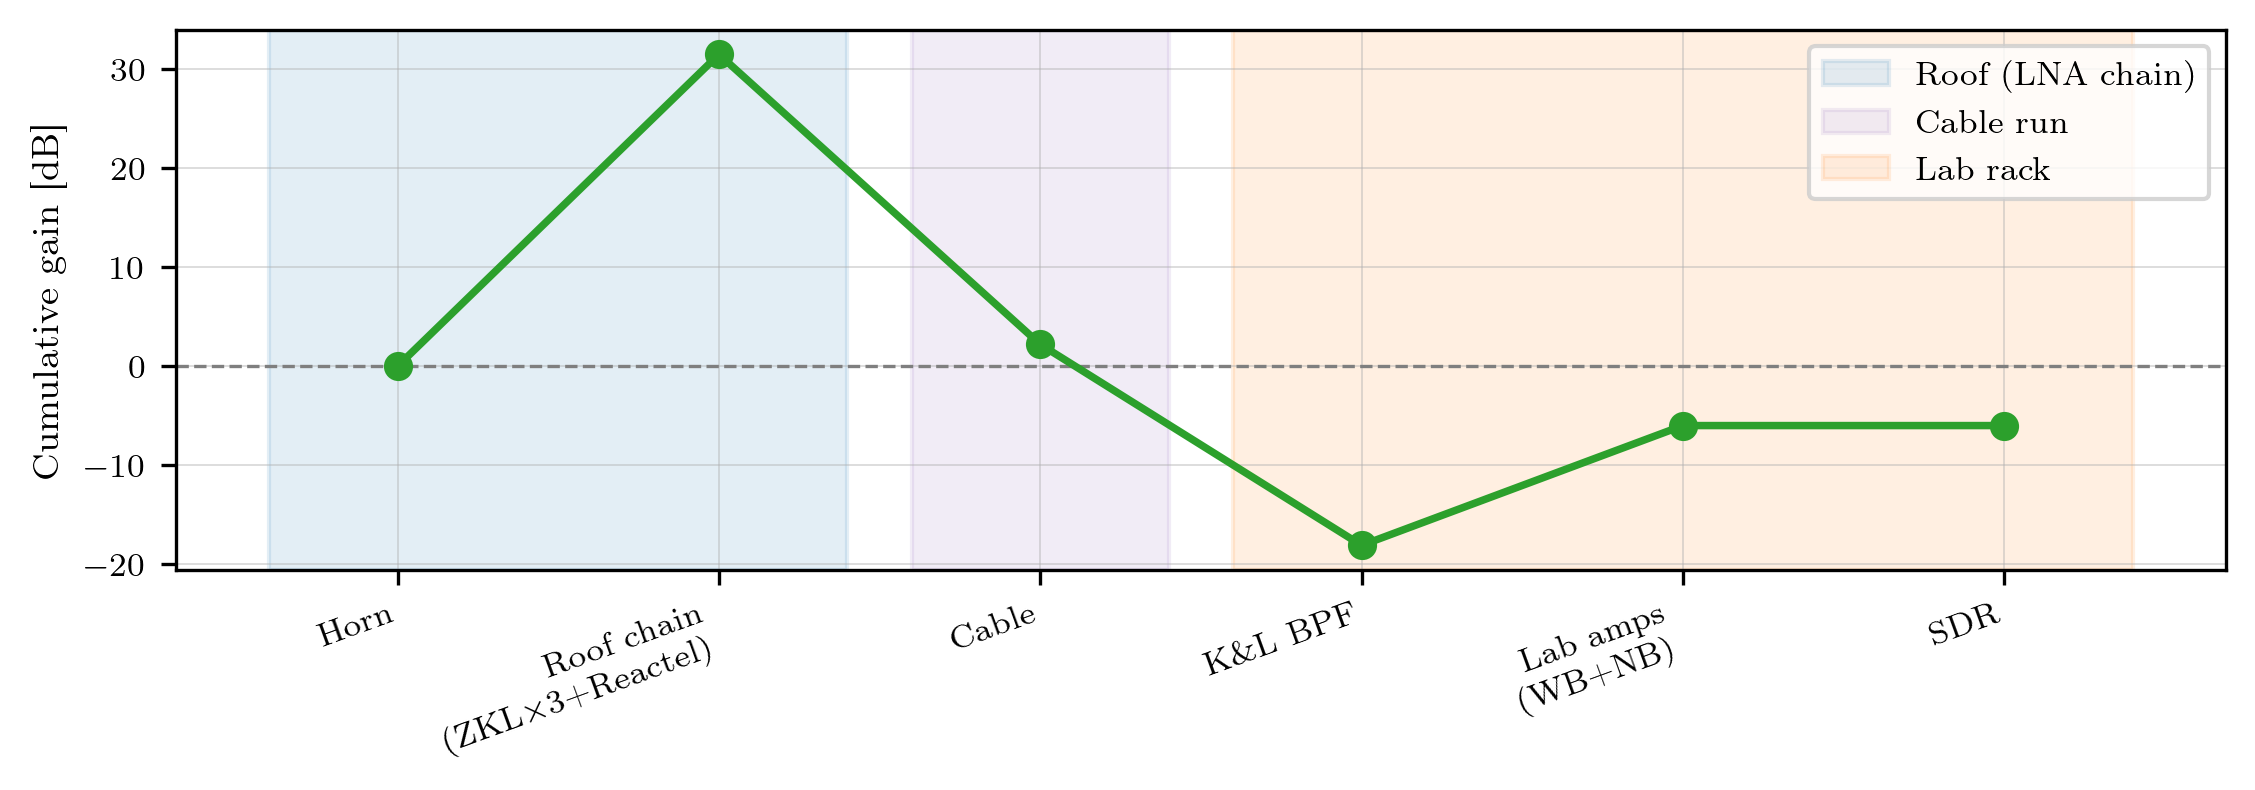

### Cable Attenuation Lo

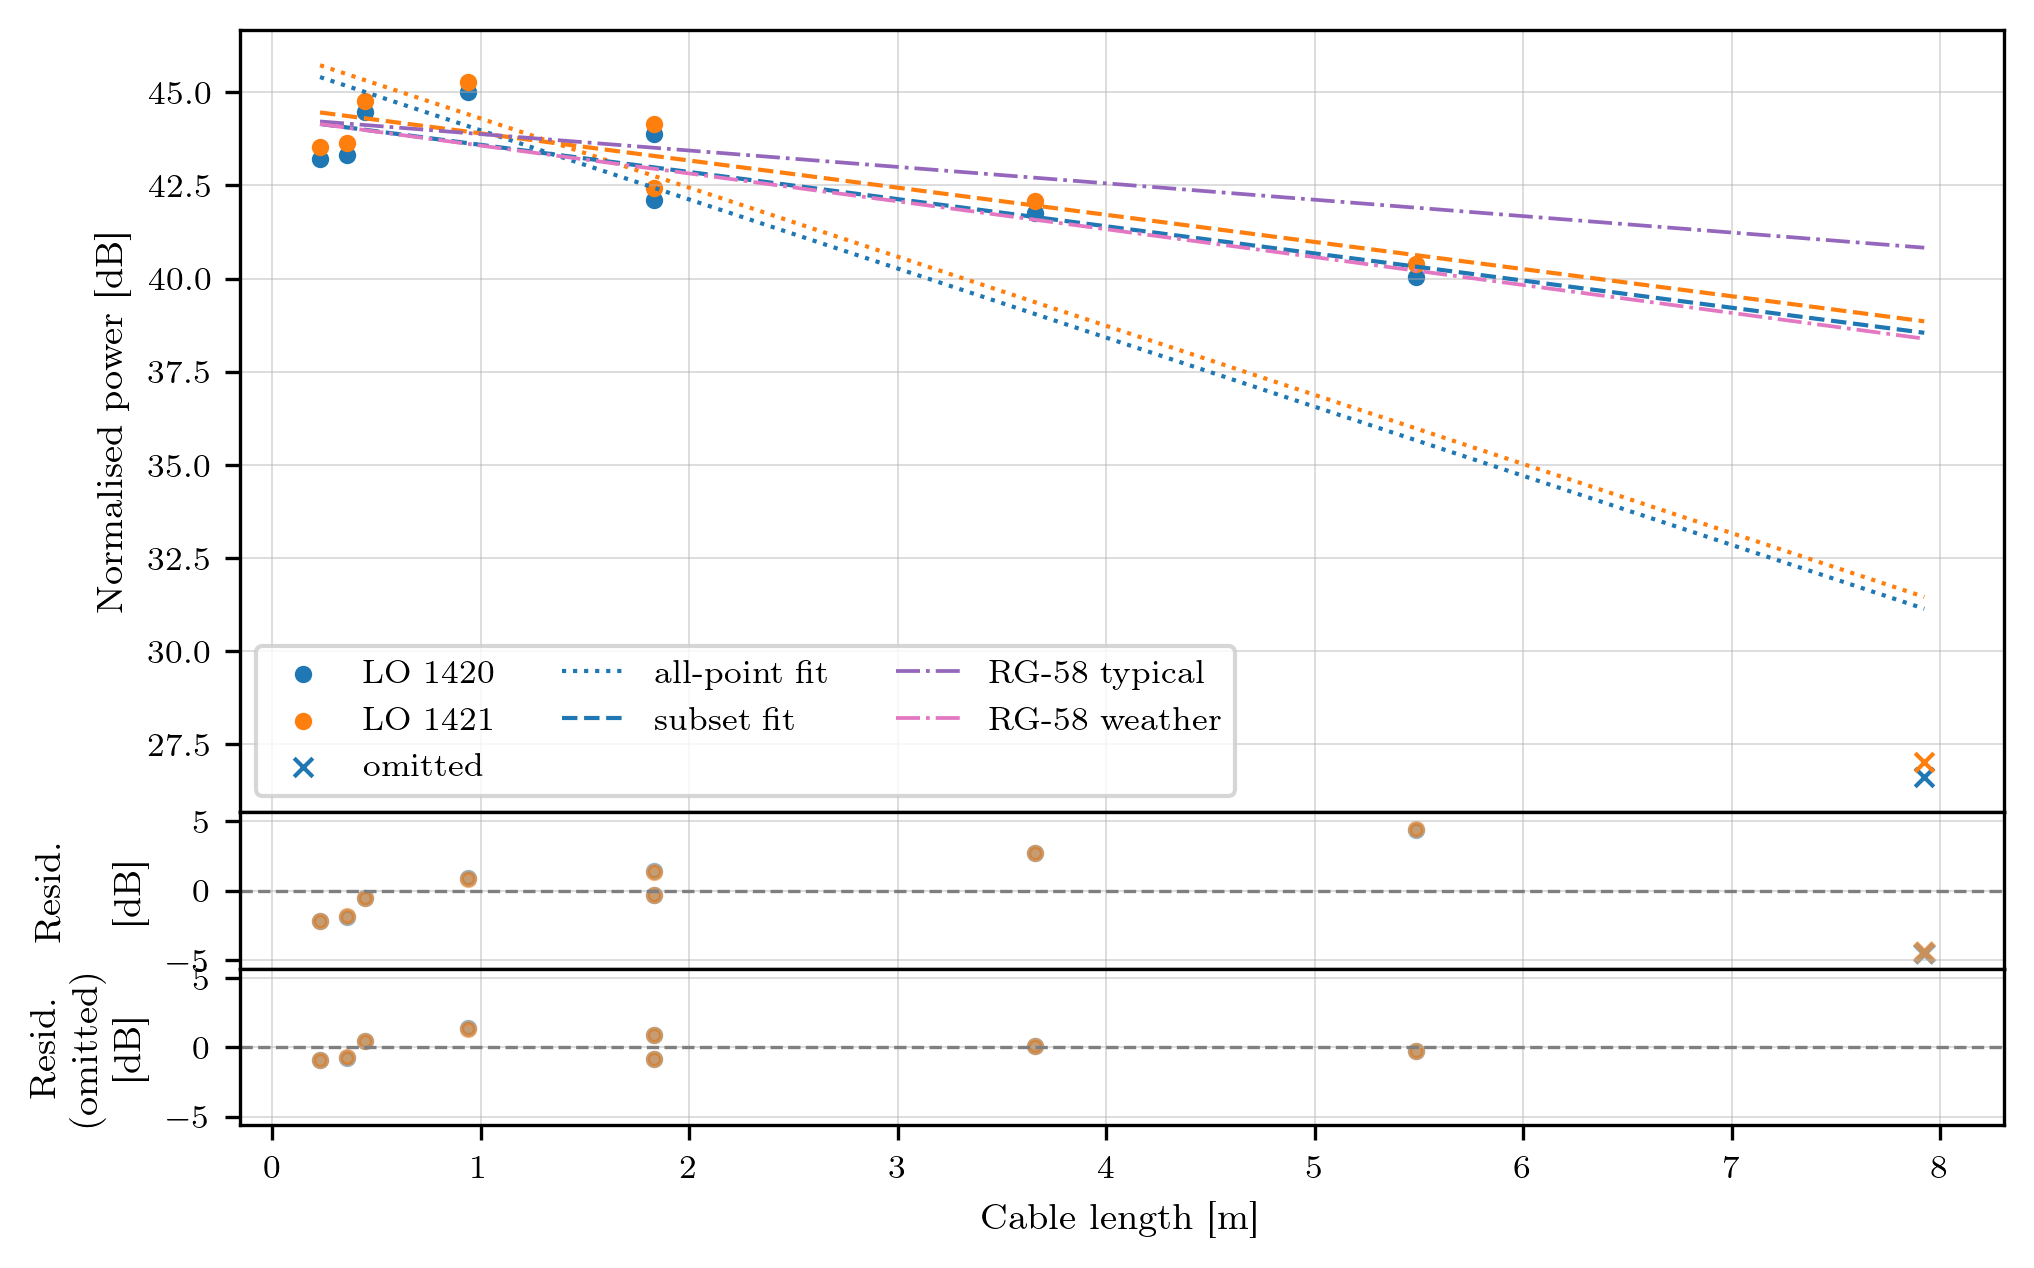

### Cable Attenuation Power Meter

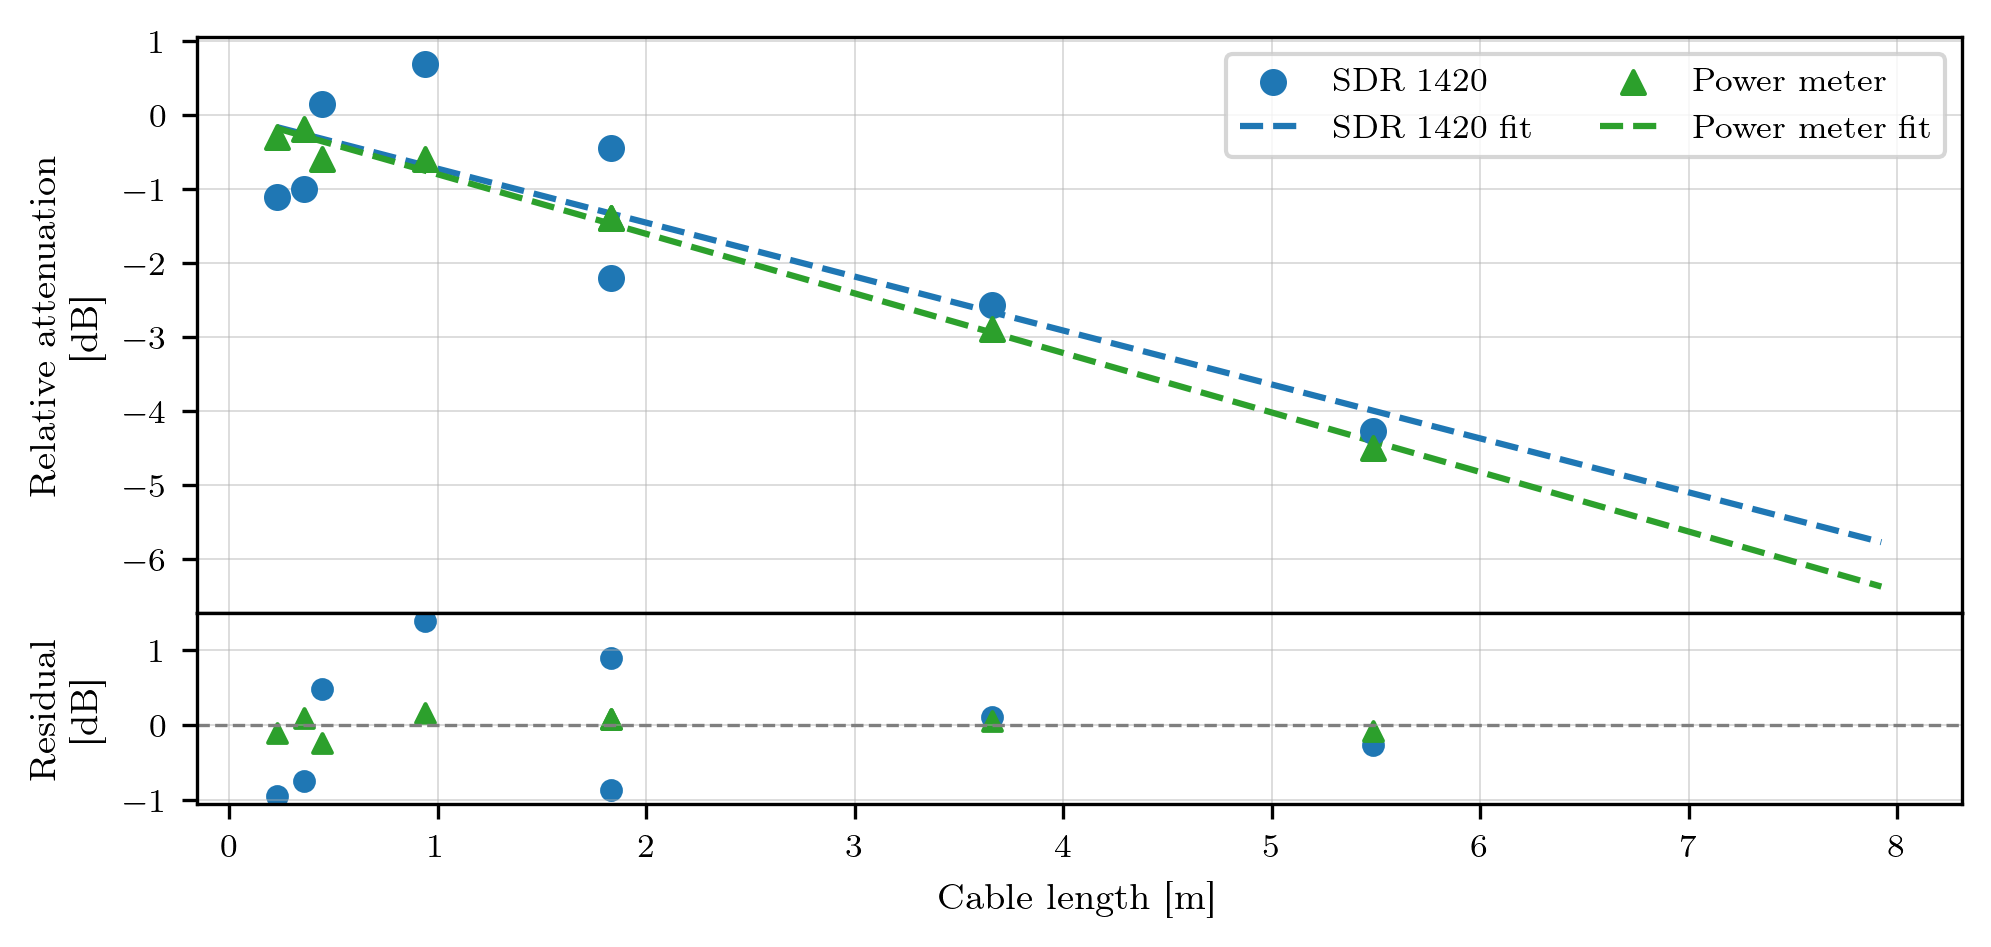

### Reflectometry

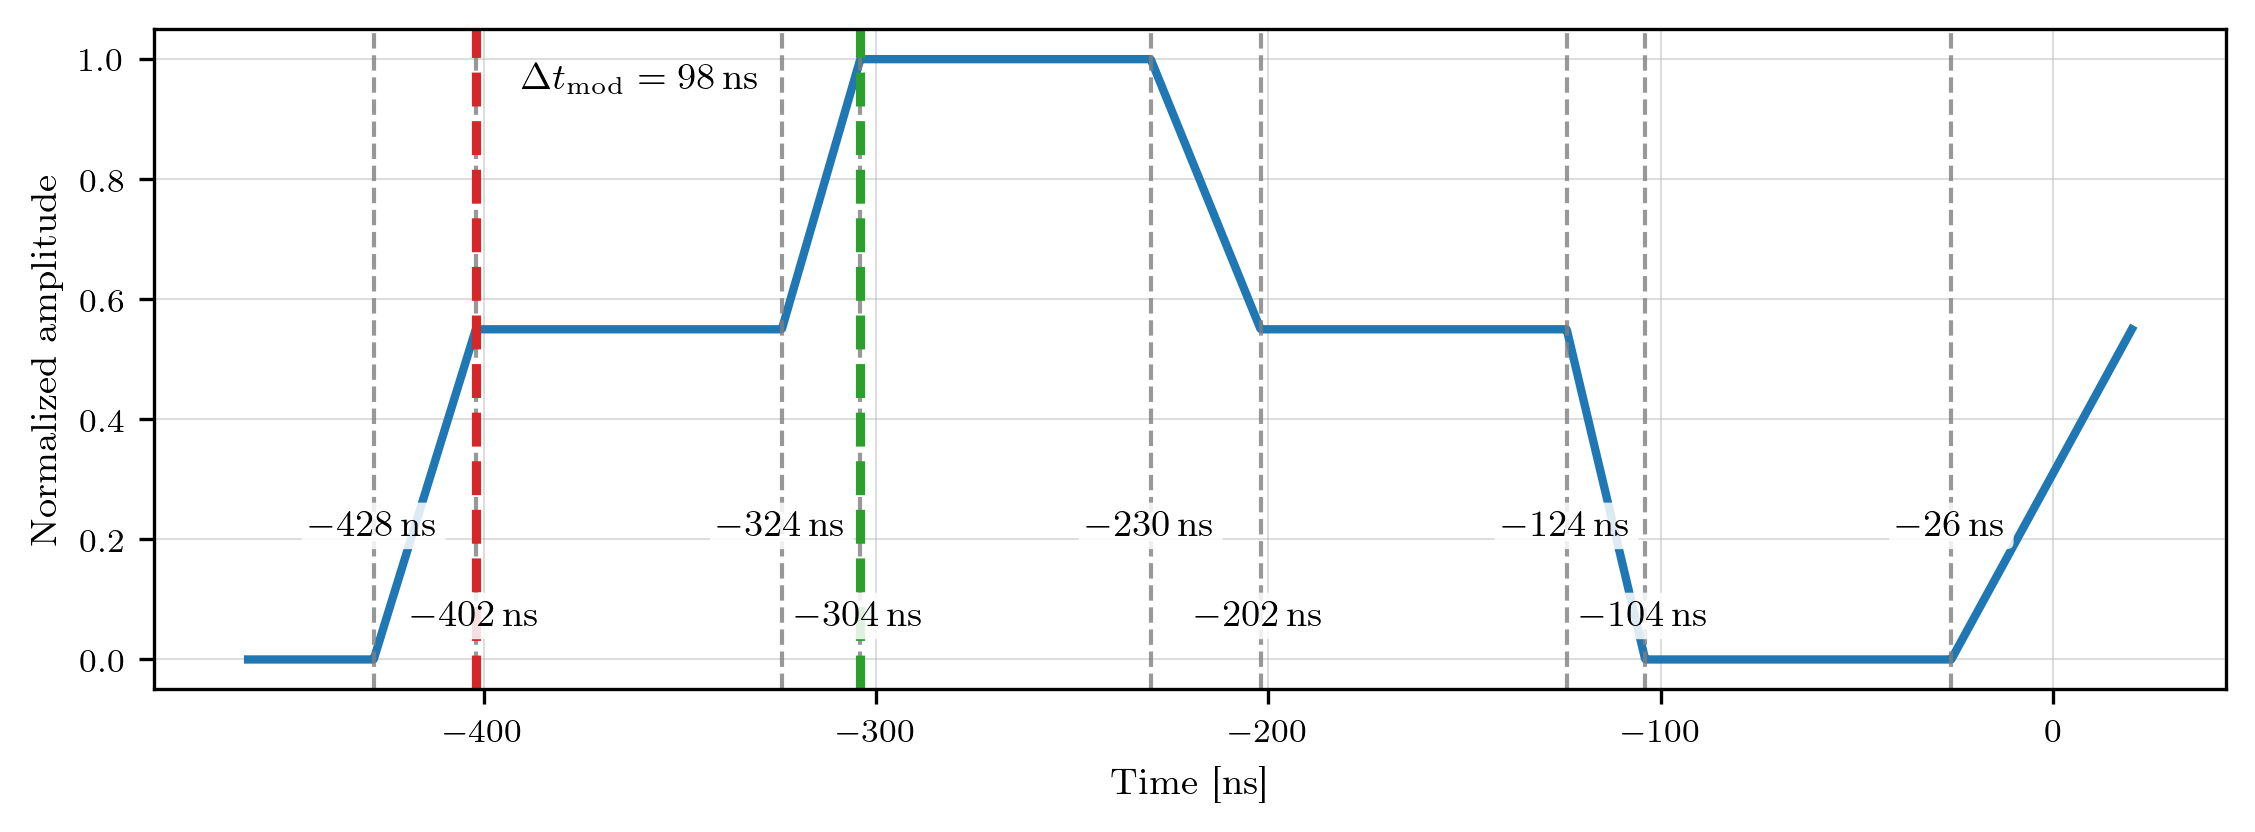

### Sdr Fir Summing Correction

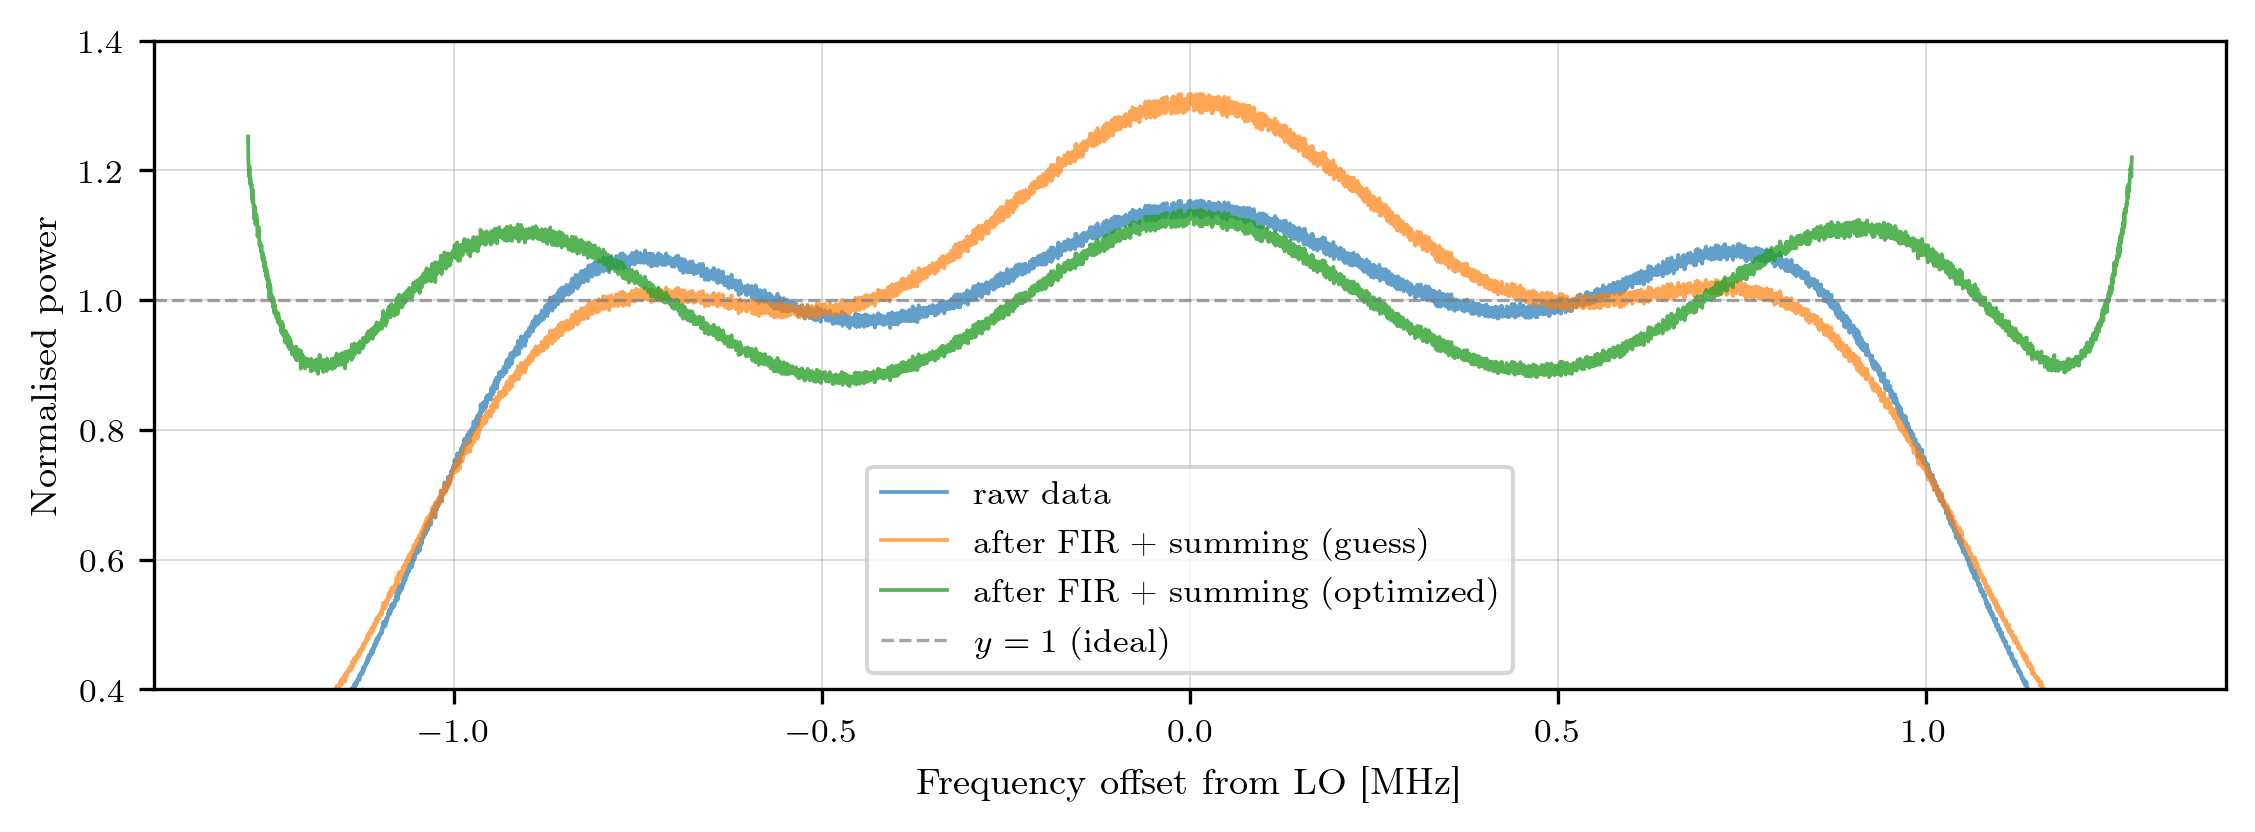

In [6]:
display(Markdown("### Response Summary"))
display(table(equipment, "response_summary"))
for name in [
    "signal_chain",
    "cable_attenuation_lo",
    "cable_attenuation_power_meter",
    "reflectometry",
    "sdr_fir_summing_correction",
]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(figure(equipment, name))

## 19) White-Noise Verification Using `cold_ref`

We use combined cold-reference spectra as a broadband proxy and evaluate whether model-based correction flattens the passband over response-supported channels.

## 20) Constrained Summing-Filter Optimization

The residual passband ripple is reduced by fitting a symmetric 11-tap summing filter (`[a,b,c,d,e,f,e,d,c,b,a]`) to minimize variance of corrected broadband power in the evaluation mask.

## 21) Export Contract (Hard Cutover to v2)

This notebook exports `equipment_calibration_results_v2.npz` under `labs/02/cache/` with `schema_version = "2.0.0"`.

The v2 artifact is grouped by semantic namespace (`model.*`, `length.*`, `response.*`, `linearity.*`, `provenance.*`, `trace.*`) and is intended to be the sole downstream contract for Part 2.

In [7]:
display(Markdown("### Bench Metrics"))
display(table(equipment, "bench_metrics"))
display(Markdown("### Bench Log"))
display(table(equipment, "bench_log"))
display(Markdown(f"Saved `{len(equipment.artifact)}` artifact fields to `{equipment.artifact_path}`."))

### Bench Metrics

,metric,value_db,sigma_db,value_pm_sigma_db
0,baseline_loss_db,4.3000,0.1414,4.300 +/- 0.141
1,unknown_incremental_loss_db,29.3000,0.1414,29.300 +/- 0.141
2,roof_chain_net_gain_db,31.5000,0.1414,31.500 +/- 0.141
3,kl_filter_incremental_loss_db,20.3000,0.1414,20.300 +/- 0.141
4,wide_narrow_net_gain_db,12.1000,0.1414,12.100 +/- 0.141
5,lab_net_vs_baseline_db,-8.2000,0.1414,-8.200 +/- 0.141


### Bench Log

,setup_id,purpose,path,p_in_dbm,p_out_dbm,p_in_sigma_dbm,p_out_sigma_dbm,chain_delta_db,chain_delta_uncertainty_db
0,A1_ref_2x6ft,Reference path (two 6-ft cables),siggen -> 6-ft -> 6-ft -> power meter,20.0000,15.7000,0.1000,0.1000,-4.3000,0.1414
1,A2_unknown_only,Unknown cable loss measurement,siggen -> 6-ft -> 6-ft -> unknown cable -> pow...,20.0000,-13.6000,0.1000,0.1000,-33.6000,0.1414
2,A3_roof_chain,Unknown cable + (ZKL + Reactel + ZKL + ZKL),A2 path + 6-ft + ZKL -> Reactel -> ZKL -> ZKL ...,20.0000,17.9000,0.1000,0.1000,-2.1000,0.1414
3,A4_lab_chain,K&L + wideband amp + narrowband amp,siggen -> 6-ft -> 6-ft -> K&L -> wideband amp ...,20.0000,7.5000,0.1000,0.1000,-12.5000,0.1414
4,A5_lab_filter_only,K&L insertion loss only,siggen -> 6-ft -> 6-ft -> K&L -> power meter,20.0000,-4.6000,0.1000,0.1000,-24.6000,0.1414


Saved `32` artifact fields to `/Users/junruiting/GitHub/ay-121/labs/02/cache/equipment_calibration_results_v2.npz`.